# Income Tax Fraud Detection — Enterprise ML Pipeline

This notebook trains a production-ready classifier on the UCI **Census Income** dataset.
High income (`>50K`) is used as a **proxy label** for elevated audit/fraud risk.

**Design principles:** reproducible splits, leakage-safe `sklearn` pipelines, imbalance-aware metrics, hyperparameter search inside CV, and serialized artifacts for the Django API in `fraud_app/`.

## 1. Configuration

In [1]:
from __future__ import annotations

import json
import logging
import warnings
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid", context="notebook")

def resolve_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "census-income.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate census-income.csv in notebook parent directories")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

NOTEBOOK_DIR = resolve_project_root()
DATA_PATH = NOTEBOOK_DIR / "census-income.csv"
ARTIFACT_DIR = NOTEBOOK_DIR / "artifacts"
MODEL_PATH = NOTEBOOK_DIR / "fraud_app" / "model.pkl"
METADATA_PATH = ARTIFACT_DIR / "model_metadata.json"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

POSITIVE_LABEL = ">50K"
NEGATIVE_LABEL = "<=50K"
TEST_SIZE = 0.20
CV_FOLDS = 5
SCORING = "f1"
N_JOBS = -1
MODEL_VERSION = "1.0.0"

FEATURE_COLUMNS = [
    "age",
    "workclass",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country",
]
TARGET_COLUMN = "income"

CATEGORICAL_FEATURES = [
    "workclass",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country",
]
NUMERIC_FEATURES = [c for c in FEATURE_COLUMNS if c not in CATEGORICAL_FEATURES]

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger("fraud-training")


## 2. Load & validate data

In [2]:
def clean_census_frame(raw: pd.DataFrame) -> pd.DataFrame:
    df = raw.copy()
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace({"?": np.nan, "": np.nan})
    return df


def validate_dataset(df: pd.DataFrame) -> None:
    expected_cols = set(FEATURE_COLUMNS + [TARGET_COLUMN])
    missing_cols = expected_cols - set(df.columns)
    if missing_cols:
        raise ValueError(f"Missing expected columns: {sorted(missing_cols)}")
    if df[TARGET_COLUMN].isna().any():
        raise ValueError("Target column contains missing values.")
    observed = sorted(df[TARGET_COLUMN].unique())
    expected_targets = sorted({POSITIVE_LABEL, NEGATIVE_LABEL})
    if observed != expected_targets:
        raise ValueError(f"Target values do not match expected labels: {observed}")


if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH.resolve()}")

raw_df = pd.read_csv(DATA_PATH)
df = clean_census_frame(raw_df)
validate_dataset(df)

missing = df[FEATURE_COLUMNS + [TARGET_COLUMN]].isna().sum()
logger.info("Loaded %s rows from %s", f"{len(df):,}", DATA_PATH.name)
display(df[FEATURE_COLUMNS + [TARGET_COLUMN]].head())
print("\nMissing values (after cleaning):")
print(missing[missing > 0].sort_values(ascending=False))
print("\nTarget distribution:")
print(df[TARGET_COLUMN].value_counts(normalize=True).round(4))


INFO | Loaded 48,842 rows from census-income.csv


,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K



Missing values (after cleaning):
occupation        2809
workclass         2799
native-country     857
dtype: int64

Target distribution:
income
<=50K    0.7607
>50K     0.2393
Name: proportion, dtype: float64


## 3. Exploratory analysis

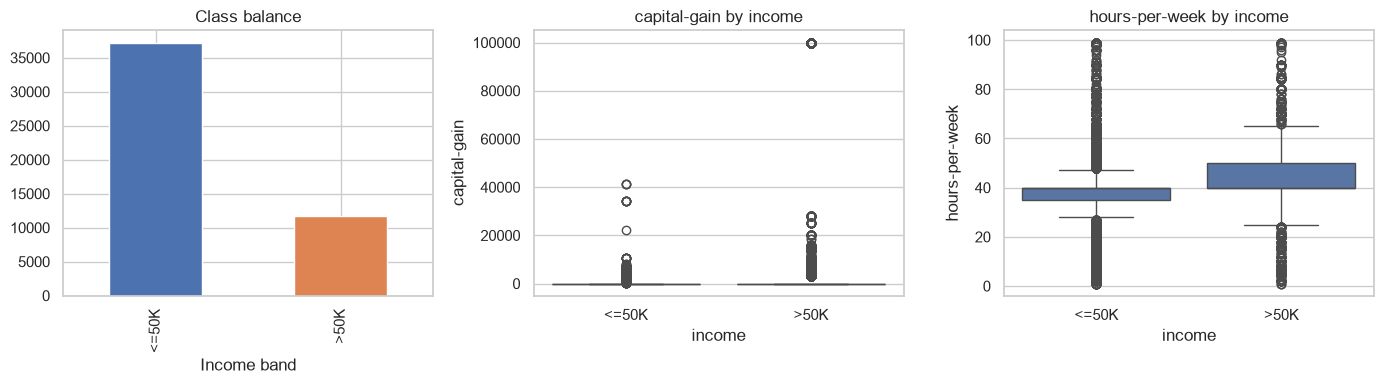

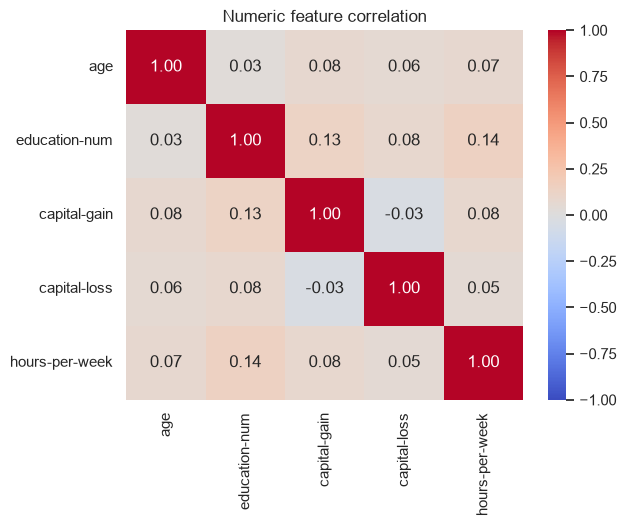

In [3]:
sns.set_theme(style="whitegrid", context="notebook")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
df[TARGET_COLUMN].value_counts().plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Class balance")
axes[0].set_xlabel("Income band")

for ax, col in zip(axes[1:], ["capital-gain", "hours-per-week"]):
    sns.boxplot(data=df, x=TARGET_COLUMN, y=col, ax=ax)
    ax.set_title(f"{col} by income")

plt.tight_layout()
plt.show()

corr_cols = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Numeric feature correlation")
plt.show()


## 4. Prepare features & stratified split

In [4]:
model_df = df[FEATURE_COLUMNS + [TARGET_COLUMN]].copy()
X = model_df[FEATURE_COLUMNS]
y = model_df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

logger.info("Train: %s | Test: %s", f"{len(X_train):,}", f"{len(X_test):,}")
print(f"Training class balance:\n{y_train.value_counts(normalize=True).round(4)}")
print(f"Test class balance:\n{y_test.value_counts(normalize=True).round(4)}")


INFO | Train: 39,073 | Test: 9,769


Training class balance:
income
<=50K    0.7607
>50K     0.2393
Name: proportion, dtype: float64
Test class balance:
income
<=50K    0.7607
>50K     0.2393
Name: proportion, dtype: float64


## 5. Leakage-safe preprocessing pipeline

In [5]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, NUMERIC_FEATURES),
        ("cat", categorical_transformer, CATEGORICAL_FEATURES),
    ],
    remainder="drop",
)


def build_pipeline(estimator) -> Pipeline:
    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", estimator),
        ]
    )


## 6. Training models

In [6]:
MODEL_SPECS = [
    ("Logistic Regression", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, solver="saga", class_weight="balanced")),
    ("Decision Tree", DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced")),
    ("Random Forest", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=N_JOBS, class_weight="balanced")),
    ("Feed Forward Neural Network", MLPClassifier(random_state=RANDOM_STATE, max_iter=1000, early_stopping=True)),
    ("k-Nearest Neighbors", KNeighborsClassifier()),
    ("Naive Bayes", GaussianNB()),
    ("Gradient Boosting", GradientBoostingClassifier(random_state=RANDOM_STATE)),
]

cv = get_cv()
training_records = []
models = []

for name, estimator in MODEL_SPECS:
    pipeline = build_pipeline(estimator)
    fit_params = {}
    if name == "Gradient Boosting":
        fit_params = {
            "classifier__sample_weight": balanced_sample_weight(y_train),
        }

    fold_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=SCORING,
        n_jobs=N_JOBS,
        fit_params=fit_params,
    )
    pipeline.fit(X_train, y_train, **fit_params)
    models.append((name, pipeline))
    training_records.append({
        "Model": name,
        "CV F1": float(np.mean(fold_scores)),
        "CV F1 Std": float(np.std(fold_scores)),
    })
    logger.info("Trained %s with CV F1=%.4f", name, np.mean(fold_scores))

training_summary = pd.DataFrame(training_records).sort_values(by="CV F1", ascending=False).reset_index(drop=True)
display(training_summary.round(4))
best_model_name = training_summary.loc[0, "Model"]
best_model = next(model for model_name, model in models if model_name == best_model_name)
logger.info("Selected best model: %s", best_model_name)


NameError: name 'MLPClassifier' is not defined

## 7. Model evaluation

In [12]:
results = []
for name, model in models:
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label=POSITIVE_LABEL),
        "Recall": recall_score(y_test, y_pred, pos_label=POSITIVE_LABEL),
        "F1 Score": f1_score(y_test, y_pred, pos_label=POSITIVE_LABEL),
        "ROC AUC": float(roc_auc_score(y_test, y_proba, pos_label=POSITIVE_LABEL)) if y_proba is not None else None,
    })
results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False).reset_index(drop=True)
print("Hold-out test performance for all candidate models:")
display(results_df.round(4))
best_model_name = results_df.loc[0, "Model"]
best_test_metrics = results_df.loc[0].to_dict()
logger.info("Best test model: %s", best_model_name)


Model Performance Metrics:


,Accuracy,Precision,Recall,F1-score
Logistic Regression,0.8050,0.5621,0.8388,0.6731
Decision Tree,0.8210,0.6338,0.5967,0.6147
Random Forest,0.8518,0.7225,0.6180,0.6662
Feed Forward Neural Network,0.8515,0.7199,0.6210,0.6668
k-Nearest Neighbors,0.8408,0.6916,0.6044,0.6451
Naive Bayes,0.5968,0.3663,0.9380,0.5268
Gradient Boosting,0.8227,0.5880,0.8661,0.7004


INFO | Best model by F1-score: Gradient Boosting


## 8. Visualisation

The model with the highest accuracy is: Random Forest with an accuracy of 0.8518.


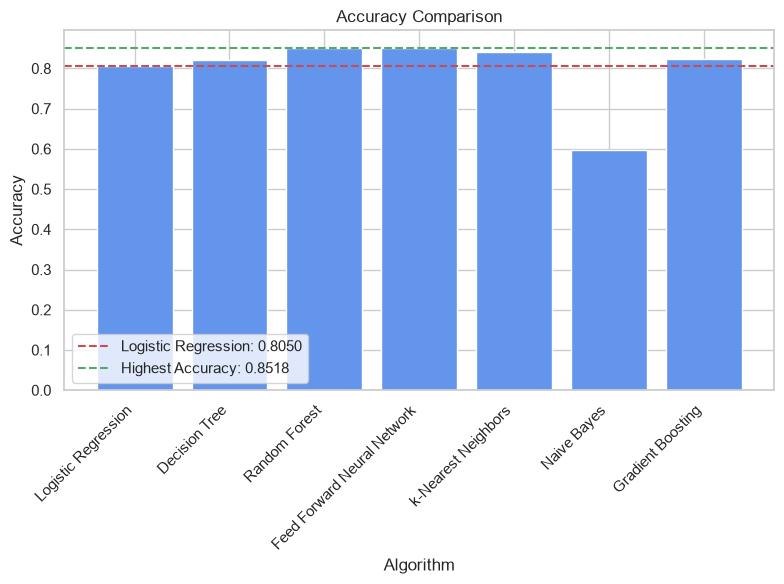

In [ ]:
# Get the accuracy of Logistic Regression, if available
lr_accuracy = results_df.loc["Logistic Regression", "Accuracy"] if "Logistic Regression" in results_df.index else None

# Find the model with the highest accuracy
highest_accuracy_model = results_df["Accuracy"].idxmax()
highest_accuracy_value = results_df["Accuracy"].max()

# Print the model with the highest accuracy
print(f"The model with the highest accuracy is: {highest_accuracy_model} with an accuracy of {highest_accuracy_value:.4f}.")

# Plotting the accuracies
plt.figure(figsize=(8, 6))
plt.bar(results_df.index, results_df["Accuracy"], color="cornflowerblue")
plt.xlabel("Algorithm")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.xticks(rotation=45, ha="right")

# Add a line for Logistic Regression accuracy, if available
if lr_accuracy is not None:
    plt.axhline(y=lr_accuracy, color="r", linestyle="--", label=f"Logistic Regression: {lr_accuracy:.4f}")

# Add a line for the highest accuracy
plt.axhline(y=highest_accuracy_value, color="g", linestyle="--", label=f"Highest Accuracy: {highest_accuracy_value:.4f}")

plt.legend()
plt.tight_layout()
plt.show()



## 9. ROC curve

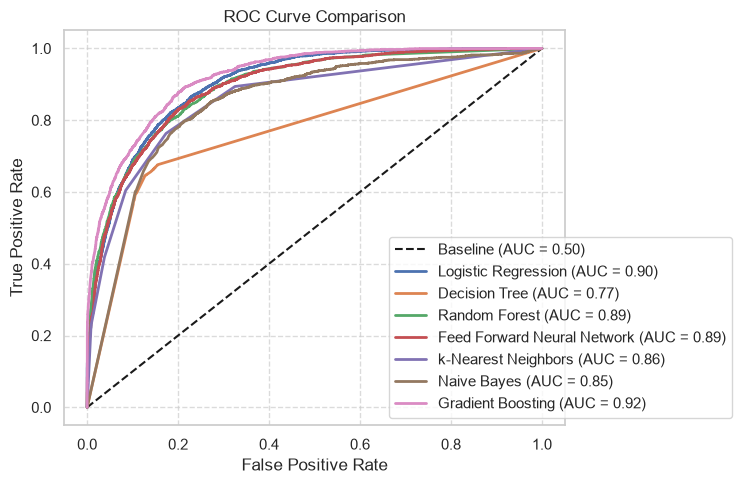

In [17]:
plt.figure(figsize=(8, 5))
plt.plot([0, 1], [0, 1], "k--", label="Baseline (AUC = 0.50)")

for name, model in models:
    if not hasattr(model, "predict_proba"):
        print(f"Model {name} doesn't support predict_proba - skipping")
        continue

    y_probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs, pos_label=POSITIVE_LABEL)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})", linewidth=2)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right", bbox_to_anchor=(1.35, 0))
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


## 10. Precision-Recall curve

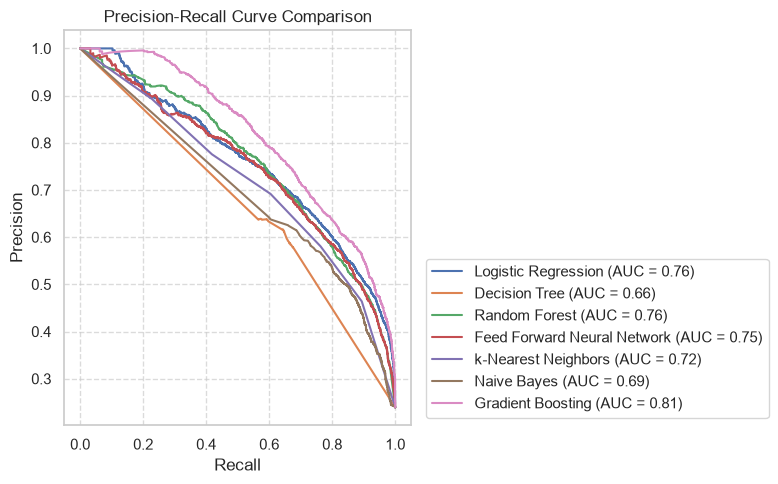

In [18]:
plt.figure(figsize=(8, 5))

for name, model in models:
    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_test)
    else:
        print(f"Model {name} doesn't support probability estimates")
        continue

    precision, recall, _ = precision_recall_curve(y_test, y_scores, pos_label=POSITIVE_LABEL)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{name} (AUC = {pr_auc:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend(loc="lower left", bbox_to_anchor=(1.02, 0))
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


## 11. Model performance comparison

In [ ]:
comparison_rows = []
for name, model in models:
    y_pred = model.predict(X_test)
    comparison_rows.append(
        {
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, pos_label=POSITIVE_LABEL),
            "Recall": recall_score(y_test, y_pred, pos_label=POSITIVE_LABEL),
            "F1 Score": f1_score(y_test, y_pred, pos_label=POSITIVE_LABEL),
        }
    )

comparison_table = pd.DataFrame(comparison_rows)
print("Model Performance Comparison:")
display(comparison_table.round(6))


## 12. Hyperparameter tuning (best model by F1)

In [ ]:
candidate_models = {name: estimator for name, estimator in MODEL_SPECS}
base_estimator = candidate_models[best_model_name]
search_pipe = build_pipeline(base_estimator)

param_spaces = {
    "Logistic Regression": {
        "classifier__C": np.logspace(-3, 2, 12),
        "classifier__penalty": ["l2"],
    },
    "Decision Tree": {
        "classifier__max_depth": [None, 8, 12, 16],
        "classifier__min_samples_leaf": [1, 2, 4],
    },
    "Random Forest": {
        "classifier__n_estimators": [100, 150, 200],
        "classifier__max_depth": [None, 12, 20],
        "classifier__min_samples_leaf": [1, 2, 4],
        "classifier__max_features": ["sqrt", "log2"],
    },
    "Feed Forward Neural Network": {
        "classifier__hidden_layer_sizes": [(64,), (128,), (64, 32)],
        "classifier__alpha": [0.0001, 0.001, 0.01],
    },
    "k-Nearest Neighbors": {
        "classifier__n_neighbors": [3, 5, 7, 11],
        "classifier__weights": ["uniform", "distance"],
    },
    "Naive Bayes": {
        "classifier__var_smoothing": np.logspace(-11, -7, 4),
    },
    "Gradient Boosting": {
        "classifier__n_estimators": [100, 150, 200],
        "classifier__learning_rate": [0.05, 0.1],
        "classifier__max_depth": [2, 3, 4],
        "classifier__subsample": [0.8, 1.0],
    },
}

fit_params = {}
if best_model_name == "Gradient Boosting":
    fit_params = {
        "classifier__sample_weight": balanced_sample_weight(y_train),
    }

search = RandomizedSearchCV(
    estimator=search_pipe,
    param_distributions=param_spaces[best_model_name],
    n_iter=16,
    scoring=SCORING,
    cv=get_cv(),
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    refit=True,
    verbose=1,
)
search.fit(X_train, y_train, **fit_params)
best_model = search.best_estimator_
print("Tuned best parameters:", search.best_params_)
print(f"Best CV {SCORING}: {search.best_score_:.4f}")


## 13. Hold-out evaluation (tuned model)

In [ ]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else best_model.decision_function(X_test)

print(classification_report(y_test, y_pred, target_names=[NEGATIVE_LABEL, POSITIVE_LABEL]))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, labels=[NEGATIVE_LABEL, POSITIVE_LABEL], ax=axes[0], cmap="Blues"
)
axes[0].set_title("Confusion matrix")
RocCurveDisplay.from_predictions(y_test, y_proba, pos_label=POSITIVE_LABEL, ax=axes[1])
axes[1].set_title("ROC curve")
plt.tight_layout()
plt.show()

holdout_metrics = {
    "roc_auc": float(roc_auc_score(y_test, y_proba)),
    "avg_precision": float(average_precision_score(y_test, y_proba, pos_label=POSITIVE_LABEL)),
    "f1": float(f1_score(y_test, y_pred, pos_label=POSITIVE_LABEL)),
}
print("Hold-out metrics:", json.dumps(holdout_metrics, indent=2))


## 14. Decision threshold tuning

In [ ]:
precision, recall, thresholds = precision_recall_curve(
    y_test, y_proba, pos_label=POSITIVE_LABEL
)
f1_scores = (2 * precision[:-1] * recall[:-1]) / np.clip(precision[:-1] + recall[:-1], 1e-9, None)
best_idx = int(np.nanargmax(f1_scores))
optimal_threshold = float(thresholds[best_idx])

plt.figure(figsize=(7, 4))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.axvline(optimal_threshold, color="black", linestyle="--", label=f"Optimal ≈ {optimal_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / recall vs threshold")
plt.legend()
plt.tight_layout()
plt.show()

y_tuned = np.where(y_proba >= optimal_threshold, POSITIVE_LABEL, NEGATIVE_LABEL)
print("Tuned-threshold confusion matrix:")
print(confusion_matrix(y_test, y_tuned, labels=[NEGATIVE_LABEL, POSITIVE_LABEL]))
print(f"Tuned F1: {f1_score(y_test, y_tuned, pos_label=POSITIVE_LABEL):.4f}")


## 15. Persist production artifacts

In [ ]:
metadata = {
    "model_family": best_model_name,
    "model_version": MODEL_VERSION,
    "trained_at": datetime.utcnow().isoformat() + "Z",
    "best_params": search.best_params_,
    "feature_columns": FEATURE_COLUMNS,
    "positive_label": POSITIVE_LABEL,
    "decision_threshold": optimal_threshold,
    "holdout_metrics": holdout_metrics,
    "random_state": RANDOM_STATE,
}

joblib.dump(best_model, MODEL_PATH)
METADATA_PATH.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

logger.info("Saved pipeline -> %s", MODEL_PATH)
logger.info("Saved metadata -> %s", METADATA_PATH)


## 16. Inference smoke test (Django-compatible payload)

In [ ]:
loaded_model = joblib.load(MODEL_PATH)

sample_payload = pd.DataFrame([
    {
        "age": 35,
        "workclass": "Private",
        "education-num": 10,
        "marital-status": "Never-married",
        "occupation": "Other-service",
        "relationship": "Not-in-family",
        "race": "White",
        "sex": "Male",
        "capital-gain": 1000,
        "capital-loss": 0,
        "hours-per-week": 40,
        "native-country": "United-States",
    }
])

sample_proba = float(loaded_model.predict_proba(sample_payload)[0, 1])
sample_label = POSITIVE_LABEL if sample_proba >= optimal_threshold else NEGATIVE_LABEL
print("Sample probability (positive class): %.3f" % sample_proba)
print("Sample decision @ threshold %.2f: %s" % (optimal_threshold, sample_label))
